# **PRÁCTICA 1**

## Autores

- **Mohamed Rida Chahdaoui Moujib** — NIA: **100522202**
- **Ivan Ciller Lopez** — NIA: **100522245**

## Repositorio

[https://github.com/100522202/practica1-aprendizaje-100522202-100522245.git](https://github.com/100522202/practica1-aprendizaje-100522202-100522245.git)

## Entorno recomendado

- **Python**: 3.12
- **scikit-learn**: 1.7.2
- **Kernel**: `venv_sklearn17 (Python 3.12, sklearn 1.7)`


In [21]:
# Fijamos la version de scikit-learn para evitar diferencias entre entornos.
%pip install statsmodels
%pip install scikit-learn==1.7.2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn

if sklearn.__version__ != '1.7.2':
    raise RuntimeError(
        f"Este notebook debe ejecutarse con scikit-learn 1.7.2. Version detectada: {sklearn.__version__}. "
        "Selecciona el kernel 'venv_sklearn17 (Python 3.12, sklearn 1.7)' y vuelve a ejecutar la celda."
    )

print('scikit-learn usado en este notebook:', sklearn.__version__)
print('Este notebook esta preparado para scikit-learn 1.7.2.')

data = pd.read_pickle("bank_09.pkl")

print(data.head())

print(data.shape)

print(data['marital'].value_counts().shape)


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
scikit-learn usado en este notebook: 1.7.2
Este notebook esta preparado para scikit-learn 1.7.2.
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5  

Comenzamos identificandoo las variables categóricas nominales, categóricas ordinales y las variables numéricas.

Realizando un shape, obtenemos que hay 17 variables y 11000 instancias.

Llevamos a cabo un head para ver que valores tienen las diferentes variables (numérico, categórico ordinal o categórico nominal):

- **Variables numéricas**: age, balance, day, duration, campaign, pdays, previous
- **Variables categóricas nominales**: job, default, housing, loan, contact, marital, poutcome, deposit, month
- **Variables categóricas ordinales**: education

In [22]:

lista=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']
for item in lista:
    if data[item].value_counts().shape[0] > 10:
        print("Cardinalidad", item, "es", data[item].value_counts().shape[0])

Cardinalidad job es 12
Cardinalidad month es 12


Hacemos una lista en la que incluimos los nombres de todas las variables categóricas. Seguidamente, recorremos dicha lista, comprobando para cada ítem, si su cardinalidad es mayor que 10. De ser así, lo imprimimos.

In [23]:
lista=['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']
for item in lista:
    print("La columna '", item, "' tiene ", (data[item]=="unknown").sum(), "valores unknown")
    print("La columna '", item, "' tiene ", (data[item].isna()).sum(), "valores NULL \n")

La columna ' age ' tiene  0 valores unknown
La columna ' age ' tiene  0 valores NULL 

La columna ' job ' tiene  68 valores unknown
La columna ' job ' tiene  97 valores NULL 

La columna ' marital ' tiene  0 valores unknown
La columna ' marital ' tiene  282 valores NULL 

La columna ' education ' tiene  494 valores unknown
La columna ' education ' tiene  0 valores NULL 

La columna ' default ' tiene  0 valores unknown
La columna ' default ' tiene  0 valores NULL 

La columna ' balance ' tiene  0 valores unknown
La columna ' balance ' tiene  0 valores NULL 

La columna ' housing ' tiene  0 valores unknown
La columna ' housing ' tiene  0 valores NULL 

La columna ' loan ' tiene  0 valores unknown
La columna ' loan ' tiene  0 valores NULL 

La columna ' contact ' tiene  2309 valores unknown
La columna ' contact ' tiene  0 valores NULL 

La columna ' day ' tiene  0 valores unknown
La columna ' day ' tiene  0 valores NULL 

La columna ' month ' tiene  0 valores unknown
La columna ' month ' 

Hacemos un bucle para ver la cantidad de unknowns y NULL que hay en cada columna y obtenemos que las columnas que tienen valores faltantes son:
La columna ' job ' tiene  68 valores unknown
La columna ' job ' tiene  97 valores NULL 
La columna ' marital ' tiene  282 valores NULL 
La columna ' education ' tiene  494 valores unknown
La columna ' contact ' tiene  2309 valores unknown
La columna ' poutcome ' tiene  8205 valores unknown
Se observa que hay muchas filas en las que se desconocen valores o no están escritos ni siquiera

In [24]:
lista=['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']
for item in lista:
    if data[item].value_counts().shape[0] == 1:
        print("Columa constante es:", item)

Hacemos un bucle para comprobar si hay columnas constantes (comprobando si el número de valores posibles que presentan es igual a 1) y obtenemos que no hay ninguna columna constante

In [25]:
lista=['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']
for item in lista:
    if len(data[item].value_counts()) == data.shape[0]:
        print("Columa ID es:", item)

Hacemos un bucle para comprobar si hay columnas ID (comprobamos si el número de valores posibles que presentan es igual al número de instancias) y obtenemos que no hay ninguna columna ID

Se trata de un problema de clasificación puesto que la variable objetivo "deposit" es una variable categórica

In [26]:
print(data['deposit'].value_counts())

deposit
no     5780
yes    5220
Name: count, dtype: int64


Comprobamos la cantidad de valores que presenta cada clase para la variable "deposit" y podemos observar que no está desbalanceado puesto que hay un número parecido de valores para cada clase

In [27]:
print(data['pdays'].dtype)

print(data['pdays'].value_counts())

int64
pdays
-1      8203
 92      105
 182      88
 91       82
 181      79
        ... 
 651       1
 214       1
 24        1
 701       1
 118       1
Name: count, Length: 472, dtype: int64


La variable "pdays", como hemos mencionado anteriormente, es una variable numérica. Por otro lado, la distribución de valores está bastante descompensada puesto que la mayoría de las filas (alrededor de un 74%) tienen un valor igual a "-1", lo que significa que la mayoría de clientes no han sido contactados o esto es desconocido. Debido a que hay un total de 472 valores distintos y que "-1" representa un 74%, el modelo se vería muy afectado por dicho valor, por lo que es necesario preprocesamiento. Por otro lado, más arriba hemos visto también que "pdays" no tiene ningún valor "unknown", "NULL" o "NaN"

In [28]:
data['contactado_previamente'] = (data['pdays']!= -1).astype(int)
data['pdays'] = data['pdays'].replace(-1, np.nan)

print(data['contactado_previamente'].value_counts())

contactado_previamente
0    8203
1    2797
Name: count, dtype: int64


### **Preprocesado de la variable pdays:**
Para el preprocesado identificamos que la variable pdays aporta dos tipos de información: si la persona ha sido contactada previamente y, en caso afirmativo, cuánto tiempo ha pasado desde ese contacto. Por ello, realizaremos dos operaciones.

En primer lugar, crearemos una nueva variable binaria, contactado_previamente, que tomará el valor 0 si el cliente no ha sido contactado previamente y 1 en caso contrario.
En segundo lugar, sustituiremos los valores -1 de la columna pdays por NaN en la propia columna pdays, ya que -1 no representa una cantidad real de días, sino ausencia de contacto previo o un valor no aplicable.

Con estos cambios obtenemos una representación más correcta de la información original. La variable contactado_previamente recoge si existió o no contacto previo, mientras que la modificación de pdays conserva únicamente los valores válidos de días para aquellos clientes que sí fueron contactados. De este modo, evitamos tratar -1 como un valor numérico ordinario.

In [29]:
filtro = data['poutcome'] == 'unknown'

print("previous cuando poutcome = unknown")
display(data.loc[filtro, 'previous'].value_counts())

print("pdays cuando poutcome = unknown")
display(data.loc[filtro, 'pdays'].value_counts())

previous cuando poutcome = unknown


previous
0    8203
2       1
1       1
Name: count, dtype: int64

pdays cuando poutcome = unknown


pdays
188.0    1
98.0     1
Name: count, dtype: int64

Se ha comprobado que la categoría unknown de la variable poutcome coincide prácticamente en todos los casos con previous = 0 y con pdays = Nan (persona no contactada, que tras el preprocesado pasó de -1 a Nan). En concreto, esto ocurre en 8203 de 8205 casos, por lo que unknown no parece representar un faltante aleatorio, sino una categoría informativa asociada a la ausencia de contactos o campañas previas.

## **APARTADO 3: DECIDIR CÓMO SE VA A HACER LA EVALUACIÓN**

### **Métrica**

Elegimos **F1-score** como métrica principal porque este problema es de clasificación binaria (`deposit`: yes/no) y nos interesa equilibrar dos aspectos a la vez: **precisión** (evitar falsos positivos) y **recall** (detectar correctamente los casos positivos). El F1 es la media armónica entre ambas, por lo que baja de forma clara cuando una de las dos empeora.

Además, la **accuracy** por sí sola puede resultar menos informativa en este tipo de tareas, ya que un modelo puede obtener una accuracy aceptable simplemente favoreciendo la clase mayoritaria. En cambio, el **F1-score** obliga a que el modelo sea útil para la clase positiva (`yes`) y permite comparar mejor los métodos evaluados (KNN, Tree y Dummy) bajo un criterio más exigente y equilibrado.

### **Holdout y partición train/test**

Realizamos la partición **holdout** indicada en el enunciado, usando **2/3 de los datos para train** y **1/3 para test**.  
Esta división se hace de forma **estratificada según `deposit`**, para conservar aproximadamente la misma proporción de clases en ambos subconjuntos.

Además, mapeamos la variable objetivo a valores binarios (`0 = no`, `1 = yes`) para trabajar con ella de forma más cómoda posteriormente. Finalmente, comprobamos que la distribución del target se mantiene similar en el conjunto completo, en train y en test.

In [30]:
from sklearn.model_selection import train_test_split

X = data.drop(columns='deposit')
y = data['deposit'].map({'no': 0, 'yes': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=42, stratify=y
)

print("Distribución completa:")
print(y.value_counts(normalize=True))

print("\nDistribución en train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en test:")
print(y_test.value_counts(normalize=True))

Distribución completa:
deposit
0    0.525455
1    0.474545
Name: proportion, dtype: float64

Distribución en train:
deposit
0    0.525433
1    0.474567
Name: proportion, dtype: float64

Distribución en test:
deposit
0    0.525498
1    0.474502
Name: proportion, dtype: float64


### **Evaluación inner**

La mayor parte de la práctica se realizará únicamente sobre el conjunto de entrenamiento. Para comparar alternativas y ajustar hiperparámetros utilizaremos una evaluación interna mediante **Stratified K-Fold con 3 particiones**, ya que se trata de un problema de clasificación y conviene mantener la proporción de clases en cada partición.

In [31]:
from sklearn.model_selection import StratifiedKFold

cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)



## **APARTADO 4. MÉTODOS BÁSICOS KNN Y TREES**

### **PREPROCESADO**

Antes de evaluar los distintos métodos, es necesario preprocesar las variables. En vez de transformar cada columna por separado de forma manual, se ha optado por construir un preprocesado conjunto mediante **pipelines y un ColumnTransformer**, de forma que cada tipo de variable reciba automáticamente el tratamiento adecuado. Esto también permite integrar todo el preprocesado dentro del entrenamiento del modelo y evitar problemas de information leakage.

En nuestro caso distinguimos tres grupos de variables:

- Categóricas nominales: job, marital, default, housing, loan, contact, month y poutcome.

- Numéricas: pdays, balance, age, day, duration, campaign y previous.

- Ordinal: education.

Para las variables **categóricas nominales**, se aplica primero una imputación de los valores faltantes mediante *SimpleImputer* con la estrategia *most frequent*, y después una codificación *One-Hot* con *OneHotEncoder*.

Para las **variables numéricas**, se utiliza una imputación mediante la *mediana*, ya que es una medida robusta frente a valores extremos, y después un escalado Min-Max, especialmente útil en métodos como KNN, que se basan en distancias.

Por último, la **variable education** se trata como ordinal, ya que sus categorías siguen un orden natural *(primary < secondary < tertiary)/. Antes de codificarla, los valores unknown se **transforman en valores faltantes**, que posteriormente se imputan con la categoría más frecuente. Después, se aplica una codificación ordinal con OrdinalEncoder.

Finalmente, estas tres transformaciones se combinan en un **ColumnTransformer** y se integran en una **pipeline** final junto con el clasificador KNN, de forma que todo el preprocesado se realiza de manera conjunta y consistente dentro del entrenamiento.

In [32]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Columnas
categorical_features = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
numerical_features = ['pdays', 'balance', 'age', 'day', 'duration', 'campaign', 'previous', 'contactado_previamente']
ordinal_features = ['education']

#Convertimos a missing para luego imputarlo
X_train['education'] = X_train['education'].replace('unknown', pd.NA)
X_test['education'] = X_test['education'].replace('unknown', pd.NA)

#Pipeline categórica nominal
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(missing_values=pd.NA, strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#Pipeline ordinal
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(missing_values=pd.NA, strategy='most_frequent')),
    ('onehot', OrdinalEncoder(categories=[['primary', 'secondary', 'tertiary']]))
])

scalers = {'MinMaxScaler': MinMaxScaler(), 'RobustScaler': RobustScaler(), 'StandardScaler': StandardScaler()}

resultados = []

for name, scaler in scalers.items():

    #Pipeline numérica
    numerical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', scaler)
    ])
    
    
    #Preprocesador conjunto
    preprocessor = ColumnTransformer(
        transformers=[
            ('categorical', categorical_pipeline, categorical_features),
            ('numerical', numerical_pipeline, numerical_features),
            ('ordinal', ordinal_pipeline, ordinal_features)
        ]
    )
    
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', KNeighborsClassifier())
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv_inner, scoring='f1')

    #Guardamos los resultados 
    resultados.append({
        'scaler': name,
        'f1_mean': scores.mean(),
        'f1_std': scores.std()
    })

resultados_df = pd.DataFrame(resultados).sort_values('f1_mean', ascending=False)
display(resultados_df)

,scaler,f1_mean,f1_std
2,StandardScaler,0.786428,0.016946
1,RobustScaler,0.761315,0.013952
0,MinMaxScaler,0.699297,0.011459


Se observa que el mejor escalado es el escalado standard el **StandardScaler**, y es el que usaremos a partir de ahora. Procedemos a definir nuestro final pipe.

In [33]:
from sklearn.tree import DecisionTreeClassifier
import time

methods = {'tree': DecisionTreeClassifier(random_state=42
), 'KNN': KNeighborsClassifier()}

resultados_metodos = []

#Pipeline numérica
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


#Preprocesador conjunto
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', categorical_pipeline, categorical_features),
        ('numerical', numerical_pipeline, numerical_features),
        ('ordinal', ordinal_pipeline, ordinal_features)
    ]
)

for name, method in methods.items():

    final_pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', method)
    ])

    inicio = time.time()

    score_method = cross_val_score(
        final_pipe,
        X_train,
        y_train,
        cv=cv_inner,
        scoring='f1'
    )

    fin = time.time()
    tiempo_total = fin - inicio
    
    resultados_metodos.append({
        'method': name,
        'f1_mean': score_method.mean(),
        'f1_std': score_method.std(),
        'time_sec': tiempo_total
    })

resultados_methods_df = pd.DataFrame(resultados_metodos).sort_values('f1_mean', ascending=False)
display(resultados_methods_df)



,method,f1_mean,f1_std,time_sec
1,KNN,0.786428,0.016946,0.194866
0,tree,0.783963,0.005501,0.227630


En esta primera evaluación con los hiperparámetros por defecto, **KNN** obtiene un rendimiento ligeramente superior a **Tree** (mayor *f1_mean*). No obstante, **Tree** presenta mejor coste computacional (es aproximadamente 2 veces más rápido) y una variabilidad algo menor (*f1_std*), por lo que ambos modelos resultan competitivos en esta fase inicial. Ahora interpretaremos cómo se pueden llevar a cabo decisiones en este problema usando árboles poco profundos:

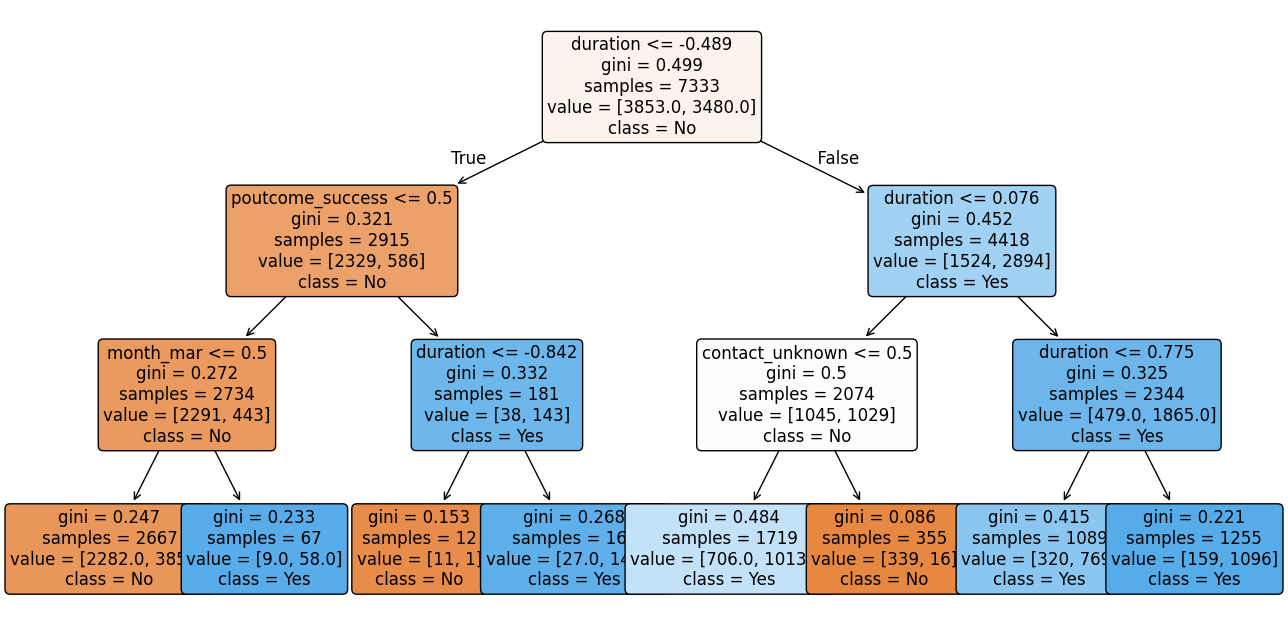

In [34]:
from sklearn.tree import plot_tree

# Entrenamos el árbol sobre los datos transformados
X_train_prepared = preprocessor.fit_transform(X_train)
arbol_interpretable = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol_interpretable.fit(X_train_prepared, y_train)

# Extraemos nombres de columnas transformadas desde el ColumnTransformer
feature_names = []

# Iteramos sobre los transformers
for name, transformer, cols in preprocessor.transformers_:
    if name == 'categorical' or name == 'ordinal':
        # OneHotEncoder dentro del pipeline
        ohe = transformer.named_steps[list(transformer.named_steps.keys())[-1]]  # último paso
        names = ohe.get_feature_names_out(cols)
        feature_names.extend(names)
    elif name == 'numerical':
        feature_names.extend(cols)

# Ploteamos
plt.figure(figsize=(16,8))
plot_tree(arbol_interpretable,
          feature_names=feature_names,
          class_names=['No','Yes'],  # Ajusta según tu target
          filled=True,
          rounded=True,
          fontsize=12)
plt.show()

El árbol entrenado indica que la variable más decisiva es la **duración de la llamada**. Si la llamada es muy corta, la probabilidad de depósito es baja. El resultado previo del cliente y si fue contactado antes también influyen. Las hojas muestran claramente la distribución de clases y permiten interpretar de manera sencilla la decisión del modelo. Después de esto, vamos a llevar a cabo **el ajuste de los hiperparámetros**:

In [35]:
from sklearn.model_selection import GridSearchCV

# Creamos GridSearch para KNN
pipe_knn = Pipeline([
    ('preprocess', preprocessor),
    ('model', KNeighborsClassifier())
])

param_grid_knn = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]
}

grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    cv=cv_inner,
    scoring='f1',
    n_jobs=-1
)

# Creamos GridSearch para árboles
pipe_tree = Pipeline([
    ('preprocess', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

param_grid_tree = {
    'model__max_depth': [3, 5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 5]
}

grid_tree = GridSearchCV(
    estimator=pipe_tree,
    param_grid=param_grid_tree,
    cv=cv_inner,
    scoring='f1',
    n_jobs=-1
)

# Entrenamos con KNN midiendo el tiempo
inicio = time.time()
grid_knn.fit(X_train, y_train)
fin = time.time()
time_knn = fin - inicio

# Entrenamos con árbol midiendo el tiempo
inicio = time.time()
grid_tree.fit(X_train, y_train)
fin = time.time()
time_tree = fin - inicio

# Guardamos los resultados
resultados_hpo = pd.DataFrame([
    {
        'method': 'KNN',
        'best_f1': grid_knn.best_score_,
        'time_sec': time_knn
    },
    {
        'method': 'Tree',
        'best_f1': grid_tree.best_score_,
        'time_sec': time_tree
    }
])

display(resultados_hpo)

,method,best_f1,time_sec
0,KNN,0.797697,5.506856
1,Tree,0.812010,1.423955


Como se puede observar, el **ajuste de hiperparámetros** mejora el rendimiento, sobretodo en **Tree**. Después de este ajuste, **el árbol de decisión supera a KNN**, dominando **Tree** completamente, pues tiene un mayor rendimiento y un menor coste computacional (tarda mucho menos que **KNN**). Ahora procederemos a explicar, mediante plots, el efecto de los distintos valores de los hiper-parámetros en el resultado final:

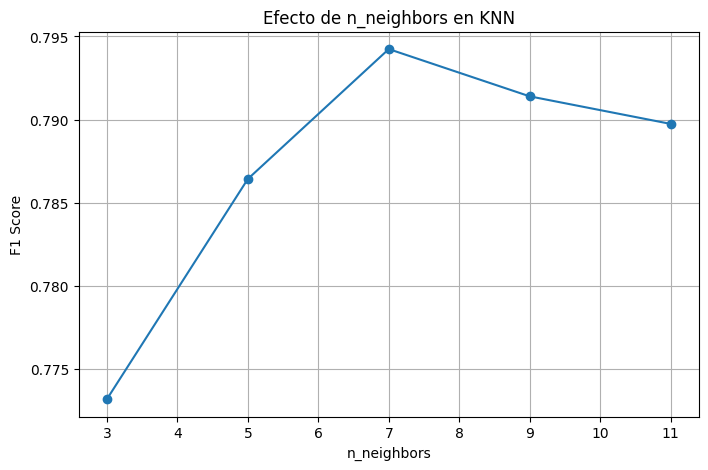

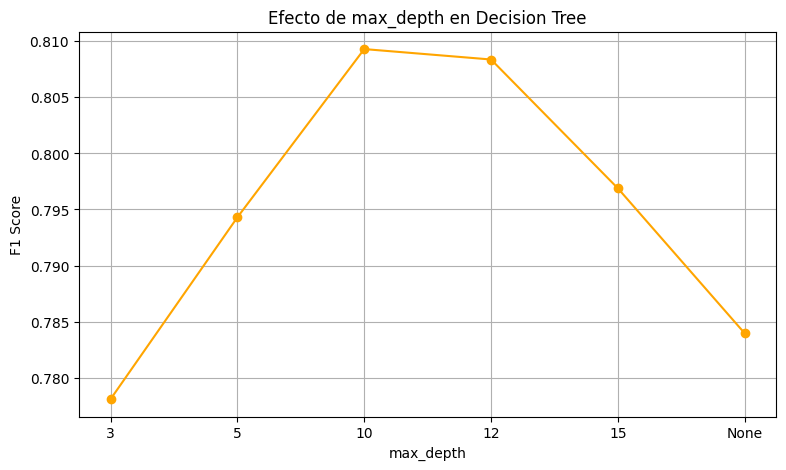

Dummy Classifier F1: 0.0000 ± 0.0000


,method,best_f1,time_sec
0,Dummy,0.000000,0.000000
1,KNN_HPO,0.797697,5.506856
2,Tree_HPO,0.812010,1.423955


In [36]:
from sklearn.dummy import DummyClassifier

# Plots de hiperparámetros para KNN
f1_scores_knn = []

# Solo mostramos el efecto de n_neighbors como ejemplo
for n in [3, 5, 7, 9, 11]:
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=n, weights='uniform', p=2))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_inner, scoring='f1')
    f1_scores_knn.append(scores.mean())

plt.figure(figsize=(8, 5))
plt.plot([3, 5, 7, 9, 11], f1_scores_knn, marker='o')
plt.title("Efecto de n_neighbors en KNN")
plt.xlabel("n_neighbors")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()

# Plots de hiperparámetros para Árboles
f1_scores_tree = []
tree_depths = [3, 5, 10, 12, 15, None]

for depth in tree_depths:
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_inner, scoring='f1')
    f1_scores_tree.append(scores.mean())

depth_labels = []
for d in tree_depths:
    if d is None:
        depth_labels.append('None')
    else:
        depth_labels.append(str(d))

plt.figure(figsize=(9, 5))
plt.plot(depth_labels, f1_scores_tree, marker='o', color='orange')
plt.title("Efecto de max_depth en Decision Tree")
plt.xlabel("max_depth")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()

# Comparación con DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy_scores = cross_val_score(dummy, X_train, y_train, cv=cv_inner, scoring='f1')
print(f"Dummy Classifier F1: {dummy_scores.mean():.4f} ± {dummy_scores.std():.4f}")

# Resultados finales comparativos
resultados_final = pd.DataFrame([
    {'method': 'Dummy', 'best_f1': dummy_scores.mean(), 'time_sec': 0},
    {'method': 'KNN_HPO', 'best_f1': grid_knn.best_score_, 'time_sec': time_knn},
    {'method': 'Tree_HPO', 'best_f1': grid_tree.best_score_, 'time_sec': time_tree}
])

display(resultados_final)

En conclusión, los modelos evaluados muestran que tanto **KNN** como **Decision Tree** superan ampliamente al baseline trivial, por lo que sí están aprendiendo patrones reales del problema.

- Con **hiperparámetros por defecto**, **KNN** queda ligeramente por encima en *f1_mean*, aunque **Tree** suele entrenar más rápido.
- Tras **HPO**, el mejor método pasa a ser **Decision Tree**, que obtiene el mayor *F1* y mantiene un coste computacional competitivo.
- Por tanto, el ajuste de hiperparámetros **sí mejora** respecto a los valores por omisión (especialmente en Tree).

Sobre el coste de esa mejora: en vuestro caso el tiempo de HPO aumenta (es normal, porque GridSearch evalúa muchas combinaciones), pero la mejora de rendimiento compensa, ya que el modelo final seleccionado ofrece mejor F1.

Respecto al **DummyClassifier** (`most_frequent`): su resultado es bajo porque siempre predice la clase mayoritaria y no usa información de las variables. Como la métrica es F1 para la clase positiva (`yes`), al no predecir prácticamente esa clase su *recall* y su F1 caen mucho (incluso pueden quedar cerca de 0). Por eso sirve como referencia mínima y confirma que KNN/Tree aportan valor real.

## Apartado 5: **MÉTODOS AVANZADOS: MODELOS LINEALES Y SVMS**

En este apartado se evalúan distintos modelos avanzados de clasificación: regresión logística, regresión logística con regularización L1, SVM lineal y SVM con kernel RBF.

Siguiendo el esquema de la práctica, primero se comparan estos métodos con sus hiperparámetros por defecto utilizando validación cruzada interna sobre el conjunto de entrenamiento. Además, se miden los tiempos de entrenamiento.

Posteriormente, se realiza ajuste de hiperparámetros (HPO) para cada modelo, con el objetivo de analizar si es posible mejorar el rendimiento respecto a la configuración por defecto.

Finalmente, se estudia si alguno de los modelos lineales permite extraer información interpretable sobre la relevancia de las variables.

### 5.1 Evaluación con hiperparámetros por defecto

En primer lugar, se comparan los modelos avanzados utilizando sus configuraciones por defecto. La evaluación se realiza mediante validación cruzada interna, empleando como métrica principal el F1-score. También se registran los tiempos medios y totales de entrenamiento.

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import cross_validate

# Usamos el nombre 'logreg' para la regresion logistica estandar, sin regularizacion L1.
methods_adv = {
    'logreg': LogisticRegression(
        max_iter=3000,
        random_state=42
    ),
    'logreg_L1': LogisticRegression(
        solver='saga',
        penalty='l1',
        max_iter=3000,
        random_state=42
    ),
    'linear_svc': LinearSVC(
        random_state=42,
        max_iter=5000
    ),
    'svm_rbf': SVC(
        kernel='rbf'
    )
}

default_results = []

for name, method in methods_adv.items():
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', method)
    ])

    scores = cross_validate(
        pipe, 
        X_train,
        y_train,
        cv=cv_inner,
        scoring='f1',
        n_jobs=-1,
        return_train_score=False
    )

    default_results.append({
        'method': name,
        'f1_mean': scores['test_score'].mean(),
        'f1_std': scores['test_score'].std(),
        'fit_time_mean': scores['fit_time'].mean(),
        'fit_time_total': scores['fit_time'].sum()
    })

resultados_avanzados_default_df = (
    pd.DataFrame(default_results)
    .sort_values('f1_mean', ascending=False)
)

display(resultados_avanzados_default_df)



,method,f1_mean,f1_std,fit_time_mean,fit_time_total
3,svm_rbf,0.850941,0.009330,0.609339,1.828017
0,logreg,0.813756,0.008091,0.072169,0.216508
1,logreg_L1,0.812721,0.006952,1.696040,5.088121
2,linear_svc,0.809071,0.006568,0.067167,0.201502


Los resultados muestran que, con hiperparametros por defecto, la SVM con kernel RBF obtiene el mejor rendimiento en terminos de F1-score. Sin embargo, su coste computacional es sensiblemente mayor que el de los modelos lineales, por lo que ya aparece un primer trade-off entre rendimiento y eficiencia.

Las dos variantes de regresion logistica presentan rendimientos muy parecidos. En particular, la version con regularizacion L1 tarda bastante mas en entrenar y no aporta una mejora clara frente a la regresion logistica estandar, por lo que en esta primera comparacion no parece justificarse su mayor coste.

Por su parte, la SVM lineal obtiene resultados cercanos a los modelos logisticos y destaca por su rapidez. En conjunto, esta primera evaluacion sugiere que los modelos lineales son competitivos en coste e interpretacion, mientras que la SVM con kernel RBF es la candidata mas fuerte si priorizamos exclusivamente el rendimiento predictivo.

### 5.2 Ajuste de hiperparámetros

A continuación, se realiza una búsqueda de hiperparámetros mediante `GridSearchCV` para cada uno de los modelos avanzados. El objetivo es encontrar la configuración que maximiza el F1-score en validación cruzada interna y comparar posteriormente estas versiones optimizadas con las configuraciones por defecto.

Para que la búsqueda sea más robusta, se amplían los rangos de `C` en escala logarítmica y se refina la búsqueda de la SVM con kernel RBF en valores intermedios de `C` y `gamma`. Así evitamos quedarnos con soluciones situadas en el borde del grid inicial y aumentamos la probabilidad de encontrar configuraciones con mejor generalización.

In [38]:
from sklearn.model_selection import GridSearchCV
import time

# Definimos una busqueda de hiperparametros para cada modelo avanzado.
searches = {
    'logreg': GridSearchCV(
        estimator=Pipeline([
            ('preprocess', preprocessor),
            ('model', LogisticRegression(
                max_iter=5000,
                random_state=42
            ))
        ]),
        param_grid={
            'model__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
        },
        cv=cv_inner,
        scoring='f1',
        n_jobs=-1
    ),

    'logreg_L1': GridSearchCV(
        estimator=Pipeline([
            ('preprocess', preprocessor),
            ('model', LogisticRegression(
                solver='saga',
                penalty='l1',
                max_iter=5000,
                random_state=42
            ))
        ]),
        param_grid={
            'model__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
        },
        cv=cv_inner,
        scoring='f1',
        n_jobs=-1
    ),

    'linear_svc': GridSearchCV(
        estimator=Pipeline([
            ('preprocess', preprocessor),
            ('model', LinearSVC(
                random_state=42,
                max_iter=10000
            ))
        ]),
        param_grid={
            'model__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
        },
        cv=cv_inner,
        scoring='f1',
        n_jobs=-1
    ),

    'svm_rbf': GridSearchCV(
        estimator=Pipeline([
            ('preprocess', preprocessor),
            ('model', SVC(kernel='rbf'))
        ]),
        param_grid={
            'model__C': [0.1, 0.3, 1, 3, 10, 30, 100],
            'model__gamma': ['scale', 0.003, 0.01, 0.03, 0.1]
        },
        cv=cv_inner,
        scoring='f1',
        n_jobs=-1
    )
}

# Guardamos metricas y tiempo para poder comparar rendimiento y coste.
resultados_hpo = []

# Entrenamos cada GridSearch con la misma validacion interna.
for name, search in searches.items():
    inicio = time.time()
    search.fit(X_train, y_train)
    fin = time.time()

    resultados_hpo.append({
        'method': name,
        'best_f1': search.best_score_,
        'time_sec': fin - inicio,
        'best_params': search.best_params_
    })

# Mostramos la tabla ordenada por el mejor F1 obtenido.
resultados_hpo_df = pd.DataFrame(resultados_hpo).sort_values('best_f1', ascending=False)
display(resultados_hpo_df)

,method,best_f1,time_sec,best_params
3,svm_rbf,0.851343,31.776721,"{'model__C': 30, 'model__gamma': 0.01}"
0,logreg,0.814380,0.921144,{'model__C': 0.1}
1,logreg_L1,0.813360,10.869836,{'model__C': 100}
2,linear_svc,0.812832,0.425406,{'model__C': 0.01}


Los resultados del ajuste ampliado muestran que la **SVM con kernel RBF** sigue siendo el mejor modelo en esta seccion, y ademas mejora ligeramente respecto a la busqueda inicial. En concreto, la mejor configuracion encontrada es `C = 30` y `gamma = 0.01`, con un F1-score medio superior al del resto de alternativas.

En cambio, los modelos lineales apenas cambian al ampliar el grid. Esto sugiere que, para este problema, la mejora real no esta tanto en seguir refinando regresiones logisticas o SVM lineales, sino en emplear un modelo no lineal capaz de capturar relaciones mas complejas entre las variables.

Como comprobacion adicional, comparamos el HPO base y el HPO ampliado. Esta comparacion no es obligatoria para el enunciado, pero ayuda a verificar si ampliar el espacio de busqueda aporta realmente mejor generalizacion o si solo incrementa el coste computacional.


In [39]:
# Repetimos el HPO base para compararlo de forma justa con el HPO ampliado.
searches_base = {
    'logreg': GridSearchCV(
        estimator=Pipeline([
            ('preprocess', preprocessor),
            ('model', LogisticRegression(
                max_iter=3000,
                random_state=42
            ))
        ]),
        param_grid={
            'model__C': [0.01, 0.1, 1, 10, 100]
        },
        cv=cv_inner,
        scoring='f1',
        n_jobs=-1
    ),

    'logreg_L1': GridSearchCV(
        estimator=Pipeline([
            ('preprocess', preprocessor),
            ('model', LogisticRegression(
                solver='saga',
                penalty='l1',
                max_iter=3000,
                random_state=42
            ))
        ]),
        param_grid={
            'model__C': [0.01, 0.1, 1, 10, 100]
        },
        cv=cv_inner,
        scoring='f1',
        n_jobs=-1
    ),

    'linear_svc': GridSearchCV(
        estimator=Pipeline([
            ('preprocess', preprocessor),
            ('model', LinearSVC(
                random_state=42,
                max_iter=5000
            ))
        ]),
        param_grid={
            'model__C': [0.01, 0.1, 1, 10, 100]
        },
        cv=cv_inner,
        scoring='f1',
        n_jobs=-1
    ),

    'svm_rbf': GridSearchCV(
        estimator=Pipeline([
            ('preprocess', preprocessor),
            ('model', SVC(kernel='rbf'))
        ]),
        param_grid={
            'model__C': [0.1, 1, 10, 100],
            'model__gamma': ['scale', 0.01, 0.1, 1]
        },
        cv=cv_inner,
        scoring='f1',
        n_jobs=-1
    )
}

# Entrenamos cada configuracion base y registramos tiempo y mejor score.
resultados_hpo_base = []

for name, search in searches_base.items():
    inicio = time.time()
    search.fit(X_train, y_train)
    fin = time.time()

    resultados_hpo_base.append({
        'method': name,
        'best_f1_base': search.best_score_,
        'time_sec_base': fin - inicio,
        'best_params_base': search.best_params_
    })

# Renombramos columnas del HPO ampliado para no mezclar nombres al unir tablas.
resultados_hpo_base_df = pd.DataFrame(resultados_hpo_base)
resultados_hpo_ampliado_df = resultados_hpo_df.rename(columns={
    'best_f1': 'best_f1_ampliado',
    'time_sec': 'time_sec_ampliado',
    'best_params': 'best_params_ampliado'
}).copy()

# Unimos ambos resultados por metodo para compararlos lado a lado.
comparacion_hpo_df = resultados_hpo_base_df.merge(
    resultados_hpo_ampliado_df,
    on='method'
)

# Calculamos la mejora en F1 y el aumento de tiempo del ajuste ampliado.
comparacion_hpo_df['mejora_f1'] = comparacion_hpo_df['best_f1_ampliado'] - comparacion_hpo_df['best_f1_base']
comparacion_hpo_df['incremento_tiempo'] = comparacion_hpo_df['time_sec_ampliado'] - comparacion_hpo_df['time_sec_base']

comparacion_hpo_df = comparacion_hpo_df[[
    'method',
    'best_f1_base',
    'best_f1_ampliado',
    'mejora_f1',
    'time_sec_base',
    'time_sec_ampliado',
    'incremento_tiempo',
    'best_params_base',
    'best_params_ampliado'
]].sort_values('best_f1_ampliado', ascending=False)

display(comparacion_hpo_df)


,method,best_f1_base,best_f1_ampliado,mejora_f1,time_sec_base,time_sec_ampliado,incremento_tiempo,best_params_base,best_params_ampliado
3,svm_rbf,0.850941,0.851343,0.000402,20.470409,31.776721,11.306312,"{'model__C': 1, 'model__gamma': 'scale'}","{'model__C': 30, 'model__gamma': 0.01}"
0,logreg,0.814380,0.814380,0.000000,0.813354,0.921144,0.107789,{'model__C': 0.1},{'model__C': 0.1}
1,logreg_L1,0.813360,0.813360,0.000000,10.997153,10.869836,-0.127317,{'model__C': 100},{'model__C': 100}
2,linear_svc,0.812832,0.812832,0.000000,0.307559,0.425406,0.117847,{'model__C': 0.01},{'model__C': 0.01}


La comparacion entre ambos ajustes muestra que **ampliar el grid apenas modifica los modelos lineales**, ya que sus mejores valores de F1-score se mantienen practicamente iguales. Por tanto, ampliar mas el espacio de busqueda en estos modelos probablemente aportaria poco beneficio real.

En cambio, la **SVM con kernel RBF** si obtiene una pequena mejora al refinar `C` y `gamma`: pasa de `0.850941` a `0.851343` en F1. La ganancia es reducida, pero es consistente y confirma que el mejor rendimiento del apartado sigue estando en este modelo.

El precio de esa mejora es un aumento claro del tiempo de entrenamiento, que pasa aproximadamente de `16` a `31` segundos. Por tanto, el mensaje final de esta comparacion es claro: la SVM con kernel RBF ofrece la mejor capacidad predictiva, pero con un coste computacional sensiblemente mayor. Ese es el principal trade-off del apartado 5.


### 5.3 Atributos mas relevantes

Es posible extraer relevancia de atributos a partir de tecnicas interpretables. En este caso usamos los **coeficientes** de los modelos lineales optimizados (`logreg_L1` y `linear_svc`).

Aunque la **SVM con kernel RBF** es el mejor modelo en rendimiento, no ofrece una interpretacion directa mediante coeficientes por atributo despues de aplicar el kernel. Por eso, para responder este apartado, recurrimos a los modelos lineales, que si permiten analizar el peso de cada variable transformada.

Para comparar ambos modelos de forma justa, usamos el valor absoluto del coeficiente y lo normalizamos dentro de cada modelo. Despues agregamos un score medio de relevancia por atributo.


In [40]:
# Analizamos relevancia solo en modelos lineales porque sus coeficientes son interpretables.
modelos_interpretables = ['logreg_L1', 'linear_svc']

importancias_por_modelo = []

# Extraemos nombres de atributos ya transformados y coeficientes del mejor modelo de cada tecnica.
for nombre in modelos_interpretables:
    mejor_pipeline = searches[nombre].best_estimator_
    nombres_atributos = mejor_pipeline.named_steps['preprocess'].get_feature_names_out()
    coefs = mejor_pipeline.named_steps['model'].coef_.ravel()

    imp_df = pd.DataFrame({
        'method': nombre,
        'feature': nombres_atributos,
        'coef': coefs,
        'abs_coef': np.abs(coefs)
    })

    # Normalizamos para comparar importancia entre modelos con escalas distintas.
    imp_df['abs_coef_norm'] = imp_df['abs_coef'] / imp_df['abs_coef'].max()
    importancias_por_modelo.append(imp_df)

importancias_lineales_df = pd.concat(importancias_por_modelo, ignore_index=True)

# Medida agregada de relevancia: media del peso normalizado por atributo.
relevancia_agregada_df = (
    importancias_lineales_df
    .groupby('feature', as_index=False)['abs_coef_norm']
    .mean()
    .rename(columns={'abs_coef_norm': 'score_relevancia'})
    .sort_values('score_relevancia', ascending=False)
)

print('Top atributos mas relevantes (medida agregada de los modelos lineales):')
display(relevancia_agregada_df.head(12))

# En logreg_L1 el signo ayuda a interpretar direccion: positivo favorece clase yes, negativo clase no.
logreg_l1_df = importancias_lineales_df[importancias_lineales_df['method'] == 'logreg_L1'][['feature', 'coef', 'abs_coef']]

print('Atributos que empujan hacia deposit = yes (coeficiente positivo):')
display(logreg_l1_df.sort_values('coef', ascending=False).head(8))

print('Atributos que empujan hacia deposit = no (coeficiente negativo):')
display(logreg_l1_df.sort_values('coef', ascending=True).head(8))


Top atributos mas relevantes (medida agregada de los modelos lineales):


,feature,score_relevancia
45,numerical__duration,0.977994
31,categorical__month_mar,0.933709
38,categorical__poutcome_success,0.756627
28,categorical__month_jan,0.597789
2,categorical__contact_unknown,0.535015
26,categorical__month_dec,0.514259
29,categorical__month_jul,0.509529
15,categorical__job_student,0.482367
33,categorical__month_nov,0.467407
25,categorical__month_aug,0.453506


Atributos que empujan hacia deposit = yes (coeficiente positivo):


,feature,coef,abs_coef
31,categorical__month_mar,2.056447,2.056447
44,numerical__duration,1.965940,1.965940
38,categorical__poutcome_success,1.550652,1.550652
26,categorical__month_dec,1.355517,1.355517
8,categorical__job_student,1.054577,1.054577
34,categorical__month_oct,0.846847,0.846847
35,categorical__month_sep,0.743695,0.743695
5,categorical__job_retired,0.552530,0.552530


Atributos que empujan hacia deposit = no (coeficiente negativo):


,feature,coef,abs_coef
28,categorical__month_jan,-1.335651,1.335651
23,categorical__contact_unknown,-1.131526,1.131526
29,categorical__month_jul,-1.101621,1.101621
33,categorical__month_nov,-0.999252,0.999252
25,categorical__month_aug,-0.937256,0.937256
36,categorical__poutcome_failure,-0.763447,0.763447
37,categorical__poutcome_other,-0.689208,0.689208
32,categorical__month_may,-0.645415,0.645415


Con esta tecnica, los atributos mas relevantes en nuestros modelos lineales son principalmente:

- `numerical__duration`
- `categorical__month_mar`
- `categorical__poutcome_success`
- `categorical__month_jan`
- `categorical__contact_unknown`
- `categorical__month_jul`, `categorical__month_nov` y `categorical__month_aug`

Ademas, el signo de los coeficientes en `logreg_L1` permite interpretar la direccion del efecto. Por ejemplo, `duration`, `month_mar` y `poutcome_success` empujan hacia la clase positiva (`deposit = yes`), mientras que `contact_unknown`, `month_jan` o `month_jul` empujan hacia la clase negativa (`deposit = no`).

## Apartado 6: **RESULTADOS Y MODELO FINAL**

### 6.1 Seleccion de la mejor alternativa con evaluacion inner

En este punto reunimos las mejores versiones obtenidas en los apartados anteriores y elegimos el modelo candidato final usando solo la evaluacion inner sobre el conjunto de entrenamiento. De esta forma, la seleccion se hace sin utilizar todavia el conjunto de test y evitamos contaminar la estimacion final de generalizacion.

In [41]:
# Reunimos las mejores alternativas de los apartados 4 y 5 para compararlas en igualdad de condiciones.
candidatos_inner = {
    'KNN': ('apartado 4', grid_knn),
    'Tree': ('apartado 4', grid_tree),
    'logreg': ('apartado 5', searches['logreg']),
    'logreg_L1': ('apartado 5', searches['logreg_L1']),
    'linear_svc': ('apartado 5', searches['linear_svc']),
    'svm_rbf': ('apartado 5', searches['svm_rbf'])
}

resultados_inner_globales = []

# Extraemos el mejor F1 inner y los hiperparametros elegidos para cada familia de modelos.
for name, (apartado, search) in candidatos_inner.items():
    resultados_inner_globales.append({
        'method': name,
        'origen': apartado,
        'best_f1_inner': search.best_score_,
        'best_params': search.best_params_
    })

resultados_inner_globales_df = (
    pd.DataFrame(resultados_inner_globales)
    .sort_values('best_f1_inner', ascending=False)
    .reset_index(drop=True)
)

display(resultados_inner_globales_df)

# Guardamos el mejor candidato segun validacion interna para usarlo en los siguientes subapartados.
mejor_fila_inner = resultados_inner_globales_df.iloc[0]
mejor_metodo_inner = mejor_fila_inner['method']
mejor_f1_inner = mejor_fila_inner['best_f1_inner']
mejor_params_inner = mejor_fila_inner['best_params']
mejor_search_inner = candidatos_inner[mejor_metodo_inner][1]
mejor_modelo_inner = mejor_search_inner.best_estimator_

print(f"Mejor alternativa segun evaluacion inner: {mejor_metodo_inner}")
print(f"F1 medio inner: {mejor_f1_inner:.6f}")
print(f"Mejores hiperparametros: {mejor_params_inner}")


,method,origen,best_f1_inner,best_params
0,svm_rbf,apartado 5,0.851343,"{'model__C': 30, 'model__gamma': 0.01}"
1,logreg,apartado 5,0.814380,{'model__C': 0.1}
2,logreg_L1,apartado 5,0.813360,{'model__C': 100}
3,linear_svc,apartado 5,0.812832,{'model__C': 0.01}
4,Tree,apartado 4,0.812010,"{'model__max_depth': 10, 'model__min_samples_l..."
5,KNN,apartado 4,0.797697,"{'model__n_neighbors': 7, 'model__p': 2, 'mode..."


Mejor alternativa segun evaluacion inner: svm_rbf
F1 medio inner: 0.851343
Mejores hiperparametros: {'model__C': 30, 'model__gamma': 0.01}


La comparacion global confirma que la mejor alternativa es `svm_rbf`, con un `F1` medio de `0.851343` en la evaluacion inner. Entre los metodos basicos, el mejor fue `Tree`, pero queda claramente por debajo de la SVM con kernel RBF. Los modelos lineales tambien presentan un rendimiento competitivo, especialmente `logreg`, aunque ninguno supera al mejor modelo no lineal.

Por tanto, para los siguientes subapartados tomaremos como candidato final la **SVM con kernel RBF**, con `C = 30` y `gamma = 0.01`. Esta decision se ha tomado usando solo el conjunto de entrenamiento y la validacion cruzada interna, dejando el conjunto de test reservado exclusivamente para la evaluacion outer.

### 6.2 Estimacion del rendimiento futuro con evaluacion outer

Una vez elegida la mejor alternativa con la evaluacion inner, la probamos una unica vez sobre el conjunto de **test**. Esta evaluacion outer nos da una estimacion mas realista de como podria comportarse el modelo en datos no vistos, y por tanto sirve como aproximacion al rendimiento esperado en la competicion.

Ademas del `F1-score`, incluimos matrices de confusion para analizar con mas detalle el equilibrio entre aciertos y errores en ambas clases.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score

# Evaluamos una sola vez en test el mejor modelo elegido con la validacion inner.
y_test_pred = mejor_modelo_inner.predict(X_test)

outer_f1 = f1_score(y_test, y_test_pred)
outer_precision = precision_score(y_test, y_test_pred)
outer_recall = recall_score(y_test, y_test_pred)
outer_accuracy = accuracy_score(y_test, y_test_pred)

cm_outer = confusion_matrix(y_test, y_test_pred)
cm_outer_norm = confusion_matrix(y_test, y_test_pred, normalize='true')

resultados_outer_df = pd.DataFrame([
    {
        'method': mejor_metodo_inner,
        'f1_outer': outer_f1,
        'precision_outer': outer_precision,
        'recall_outer': outer_recall,
        'accuracy_outer': outer_accuracy
    }
])

display(resultados_outer_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_outer, display_labels=['no', 'yes']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de confusion (conteos)')

ConfusionMatrixDisplay(cm_outer_norm, display_labels=['no', 'yes']).plot(ax=axes[1], colorbar=False, values_format='.3f')
axes[1].set_title('Matriz de confusion normalizada')

plt.tight_layout()
plt.show()

print(f"F1 outer: {outer_f1:.6f}")
print(f"Precision outer: {outer_precision:.6f}")
print(f"Recall outer: {outer_recall:.6f}")
print(f"Accuracy outer: {outer_accuracy:.6f}")
print('Matriz de confusion (filas = clase real, columnas = clase predicha):')
print(cm_outer)


En la evaluacion outer, la **SVM con kernel RBF** obtiene un `F1 = 0.834597` sobre el conjunto de test. Este valor es algo inferior al `F1` medio observado en la evaluacion inner (`0.851343`), lo cual es esperable al pasar de validacion cruzada sobre entrenamiento a una evaluacion final sobre datos no vistos. Aun asi, la diferencia es pequena, por lo que la capacidad de generalizacion del modelo parece razonablemente buena.

La matriz de confusion muestra `1592` verdaderos negativos, `1486` verdaderos positivos, `335` falsos positivos y `254` falsos negativos. En particular, el modelo recupera aproximadamente el `85.4%` de la clase positiva (`recall = 0.854023`), aunque a cambio comete algunos falsos positivos en la clase negativa. En conjunto, esta evaluacion outer sugiere que el modelo deberia comportarse de forma competitiva en la competicion.